In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import label_binarize

from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import NearMiss


In [29]:
# 1. Carga de datos 
df = pd.read_csv('processed_matches.csv')

In [25]:
df.shape

(49971, 209)

In [3]:
df

,home_rank_position,home_rank_points,away_rank_position,away_rank_points,rank_points_diff,year,neutral,has_shootout,tourn_AFC Asian Cup,tourn_AFC Asian Cup qualification,...,tourn_World Unity Cup,tourn_Zambian Independence Tournament,tourn_Évence Coppée Trophy,home_score,away_score,ranking_diff,goal_diff,result,is_home,ranking_scaled
0,38.0,1506.77,4.0,1834.12,-327.35,1872,0,0,False,False,...,False,False,False,0.0,0.0,-327.35,0.0,draw,1,0.512611
1,4.0,1834.12,38.0,1506.77,327.35,1873,0,0,False,False,...,False,False,False,4.0,2.0,327.35,2.0,win,1,1.798387
2,38.0,1506.77,4.0,1834.12,-327.35,1874,0,0,False,False,...,False,False,False,2.0,1.0,-327.35,1.0,win,1,0.512611
3,4.0,1834.12,38.0,1506.77,327.35,1875,0,0,False,False,...,False,False,False,2.0,2.0,327.35,0.0,draw,1,1.798387
4,38.0,1506.77,4.0,1834.12,-327.35,1876,0,0,False,False,...,False,False,False,3.0,0.0,-327.35,3.0,win,1,0.512611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49966,87.0,1272.19,73.0,1347.88,-75.69,2025,0,0,False,False,...,False,False,False,2.0,1.0,-75.69,1.0,win,1,-0.408780
49967,38.0,1506.77,21.0,1616.75,-109.98,2025,0,0,False,False,...,False,False,False,4.0,2.0,-109.98,2.0,win,1,0.512611
49968,79.0,1308.84,18.0,1654.69,-345.85,2025,0,0,False,False,...,False,False,False,1.0,1.0,-345.85,0.0,draw,1,-0.264825
49969,27.0,1574.01,53.0,1461.46,112.55,2022,0,0,False,False,...,False,False,False,0.0,0.0,112.55,0.0,draw,1,0.776718


In [30]:
df['result'].value_counts()

result
win     24499
lose    14123
draw    11349
Name: count, dtype: int64

In [31]:
# FEATURE ENGINEERING

# Diferencias y relaciones
df['rank_position_diff'] = df['away_rank_position'] - df['home_rank_position']
df['rank_points_diff'] = df['home_rank_points'] - df['away_rank_points']
df['rank_points_sum'] = df['home_rank_points'] + df['away_rank_points']
df['rank_points_ratio'] = df['home_rank_points'] / (df['away_rank_points'] + 1)
df['abs_rank_points_diff'] = df['rank_points_diff'].abs()

# Transformaciones
df['log_home_rank_points'] = np.log1p(df['home_rank_points'])
df['log_away_rank_points'] = np.log1p(df['away_rank_points'])
df['inv_home_rank_position'] = 1 / (df['home_rank_position'] + 1)
df['inv_away_rank_position'] = 1 / (df['away_rank_position'] + 1)

# Feature útil para empates
df['is_close_match'] = (df['abs_rank_points_diff'] < 50).astype(int)

In [32]:
# TARGET MULTICLASE
# 0 = lose, 1 = draw, 2 = win
df['target'] = np.select(
    [
        df['home_score'] > df['away_score'],
        df['home_score'] == df['away_score'],
        df['home_score'] < df['away_score']
    ],
    [2, 1, 0]
)


df['has_shootout'] = df['has_shootout'].astype(int)
df['neutral'] = df['neutral'].fillna(0).astype(int)

In [33]:
df['target'].value_counts()

target
2    24499
0    14123
1    11349
Name: count, dtype: int64

In [35]:
# DETECTAR DUMMIES EXISTENTES
tournament_features = [col for col in df.columns if col.startswith('tourn_')]
len(tournament_features)

194

In [36]:
# Transformar dummies a binarias
for col in tournament_features:
    df[col] = df[col].apply(lambda x: 1 if x > 0 else 0)

In [37]:
# FEATURES
rank_features = [
    'home_rank_position',
    'home_rank_points',
    'away_rank_position',
    'away_rank_points',
    'rank_points_diff'
]

engineered_features = [
    'rank_position_diff',
    'rank_points_sum',
    'rank_points_ratio',
    'abs_rank_points_diff',
    'log_home_rank_points',
    'log_away_rank_points',
    'inv_home_rank_position',
    'inv_away_rank_position',
    'is_close_match'
]

other_features = [
    'year',
    'neutral',
    'has_shootout'
]

features = rank_features + engineered_features + other_features + tournament_features
len(features)

211

In [38]:
# DATASET MODELO
target = 'target'
df_final = df[features + [target]]

# SPLIT
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Modelos

## Random Forest

In [ ]:
# Definir modelo
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

In [ ]:
# Entrenar modelo
rf_model.fit(X_train, y_train)

In [ ]:
# Predicciones
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)

In [40]:
y_pred_rf

array([0, 2, 2, ..., 2, 2, 0], shape=(9995,))

In [41]:
y_proba_rf

array([[0.8       , 0.085     , 0.115     ],
       [0.00808222, 0.01691778, 0.975     ],
       [0.015     , 0.15247678, 0.83252322],
       ...,
       [0.145     , 0.175     , 0.68      ],
       [0.21      , 0.005     , 0.785     ],
       [0.54      , 0.115     , 0.345     ]], shape=(9995, 3))

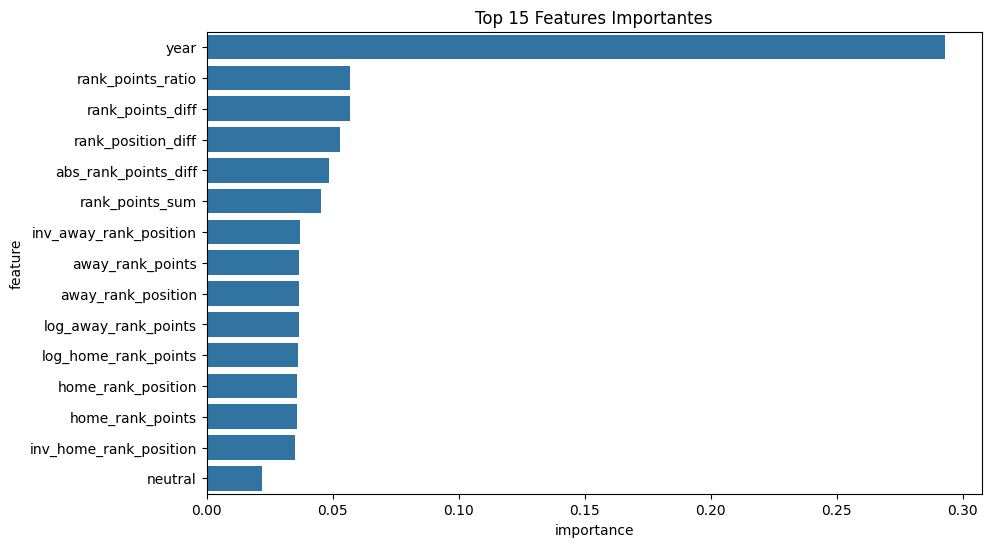

In [47]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Top 15 Features Importantes')
plt.show()


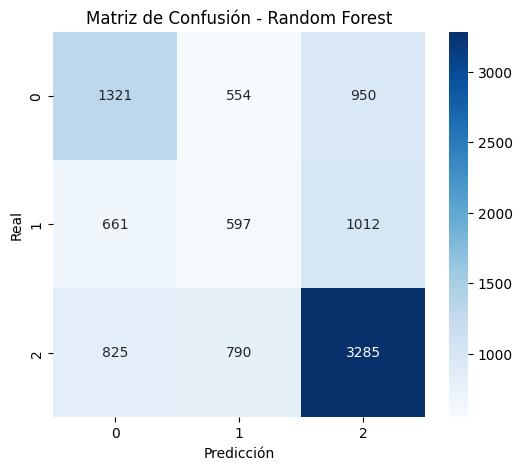

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

           0       0.47      0.47      0.47      2825
           1       0.31      0.26      0.28      2270
           2       0.63      0.67      0.65      4900

    accuracy                           0.52      9995
   macro avg       0.47      0.47      0.47      9995
weighted avg       0.51      0.52      0.51      9995



In [42]:
# MAtriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred_rf))


In [55]:
# AUC MULTICLASE
classes = rf_model.classes_

y_test_bin = label_binarize(y_test, classes=classes)

# AUC
auc_macro = roc_auc_score(y_test_bin, y_proba_rf, average='macro', multi_class='ovr')
auc_weighted = roc_auc_score(y_test_bin, y_proba_rf, average='weighted', multi_class='ovr')

print(f"AUC Macro: {auc_macro:.4f}")
print(f"AUC Weighted: {auc_weighted:.4f}")

AUC Macro: 0.6652
AUC Weighted: 0.6783


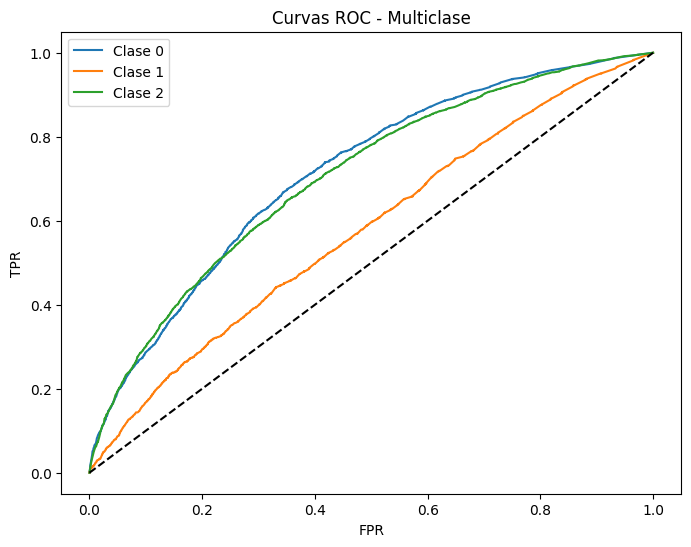

In [56]:
# Curvas ROC
plt.figure(figsize=(8,6))

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_rf[:, i])
    plt.plot(fpr, tpr, label=f'Clase {class_label}')

plt.plot([0,1], [0,1], 'k--')
plt.title('Curvas ROC - Multiclase')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

In [57]:
gini_macro = 2 * auc_macro - 1
print(f"Gini (macro): {gini_macro:.4f}")


Gini (macro): 0.3304


In [58]:
# KS
def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)

print("\nKS por clase:")
for i, class_label in enumerate(classes):
    ks = ks_statistic(y_test_bin[:, i], y_proba_rf[:, i])
    print(f"Clase {class_label}: KS = {ks:.4f}")


KS por clase:
Clase 0: KS = 0.3244
Clase 1: KS = 0.1107
Clase 2: KS = 0.2976


In [59]:
# Errores
errors = X_test.copy()
errors['y_true'] = y_test.values
errors['y_pred'] = y_pred_rf
errors['correct'] = (errors['y_true'] == errors['y_pred'])

error_rate = 1 - errors['correct'].mean()
print(f"\nError rate: {error_rate:.4f}")

# Ver ejemplos de errores
print("\nEjemplos de errores:")
display(errors[errors['correct'] == False].head())


Error rate: 0.4794

Ejemplos de errores:


,home_rank_position,home_rank_points,away_rank_position,away_rank_points,rank_points_diff,rank_position_diff,rank_points_sum,rank_points_ratio,abs_rank_points_diff,log_home_rank_points,...,tourn_World Cup,tourn_World Cup - Qualification CONCACAF,tourn_World Cup - Qualification Europe,tourn_World Cup - Qualification Intercontinental Play-offs,tourn_World Unity Cup,tourn_Zambian Independence Tournament,tourn_Évence Coppée Trophy,y_true,y_pred,correct
22871,128.0,1128.50,1.0,1877.18,-748.68,-127.0,3005.68,0.600848,748.68,7.029530,...,0,0,0,0,0,0,0,2,0,False
19596,49.0,1465.78,57.0,1447.31,18.47,8.0,2913.09,1.012062,18.47,7.290825,...,0,0,0,0,0,0,0,1,2,False
37987,40.0,1501.50,53.0,1461.46,40.04,13.0,2962.96,1.026695,40.04,7.314886,...,0,0,0,0,0,0,0,2,1,False
40223,65.0,1379.54,51.0,1464.24,-84.70,-14.0,2843.78,0.941511,84.70,7.230230,...,0,0,0,0,0,0,0,1,2,False
33709,24.0,1585.51,18.0,1654.69,-69.18,-6.0,3240.20,0.957613,69.18,7.369292,...,0,0,0,0,0,0,0,0,2,False


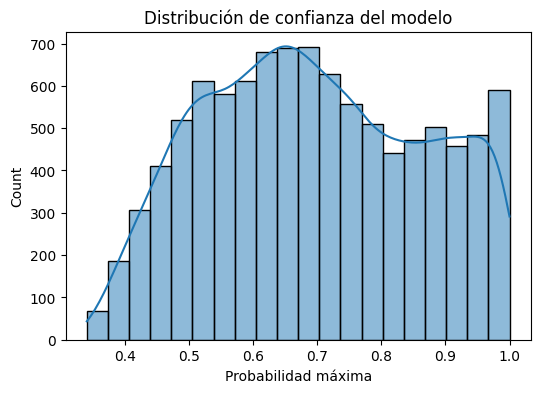

In [50]:
# Ps
confidence = np.max(y_proba_rf, axis=1)

plt.figure(figsize=(6,4))
sns.histplot(confidence, bins=20, kde=True)
plt.title('Distribución de confianza del modelo')
plt.xlabel('Probabilidad máxima')
plt.show()

### Random Forest sin variable year, con empates

In [60]:
X_train.head()

,home_rank_position,home_rank_points,away_rank_position,away_rank_points,rank_points_diff,rank_position_diff,rank_points_sum,rank_points_ratio,abs_rank_points_diff,log_home_rank_points,...,tourn_WAFF Championship,tourn_West African Cup,tourn_Windward Islands Tournament,tourn_World Cup,tourn_World Cup - Qualification CONCACAF,tourn_World Cup - Qualification Europe,tourn_World Cup - Qualification Intercontinental Play-offs,tourn_World Unity Cup,tourn_Zambian Independence Tournament,tourn_Évence Coppée Trophy
26126,63.0,1401.07,127.0,1132.97,268.10,64.0,2534.04,1.235544,268.10,7.245705,...,0,0,0,0,0,0,0,0,0,0
46323,102.0,1218.91,71.0,1362.37,-143.46,-31.0,2581.28,0.894042,143.46,7.106532,...,0,0,0,0,0,0,0,0,0,0
17421,89.0,1263.09,134.0,1105.96,157.13,45.0,2369.05,1.141044,157.13,7.142108,...,0,0,0,0,0,0,0,0,0,0
43351,105.0,1196.08,66.0,1378.57,-182.49,-39.0,2574.65,0.866995,182.49,7.087641,...,0,0,0,0,0,0,0,0,0,0
4570,10.0,1724.15,42.0,1487.13,237.02,32.0,3211.28,1.158602,237.02,7.453069,...,0,0,0,0,0,0,0,0,0,0


In [61]:
X_train['year']

26126    2002
46323    2023
17421    1990
43351    2020
4570     1957
         ... 
31043    2007
49041    2023
31356    2008
17055    1990
46088    2023
Name: year, Length: 39976, dtype: int64

In [63]:
X_train['year'].describe()

count    39976.000000
mean      1994.262182
std         25.504495
min       1872.000000
25%       1980.000000
50%       2000.000000
75%       2014.000000
max       2025.000000
Name: year, dtype: float64

In [78]:
# Eliminando 'year'
if 'year' in features:
    features.remove('year')

# Reconstruir X
X = df[features]
y = df['target']

# Split nuevamente
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [79]:
# Definir modelo
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

In [80]:
# Entrenar modelo
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [81]:
# Predicciones
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)

In [82]:
y_pred_rf

array([0, 2, 2, ..., 2, 2, 2], shape=(9995,))

In [83]:
y_proba_rf

array([[0.74355775, 0.10007145, 0.15637079],
       [0.        , 0.        , 1.        ],
       [0.005     , 0.11547533, 0.87952467],
       ...,
       [0.09162777, 0.08364433, 0.8247279 ],
       [0.29916502, 0.        , 0.70083498],
       [0.29857288, 0.32748025, 0.37394687]], shape=(9995, 3))

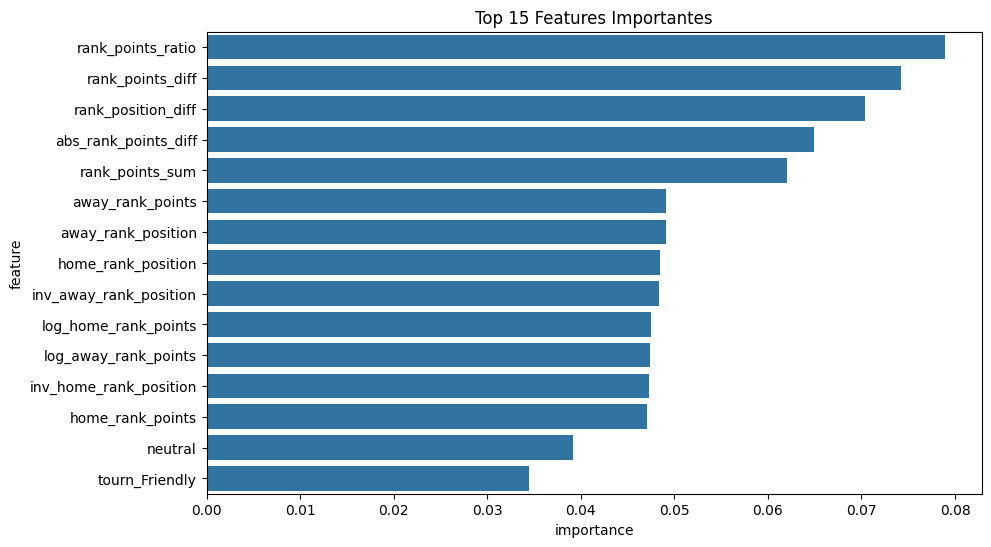

In [84]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Top 15 Features Importantes')
plt.show()


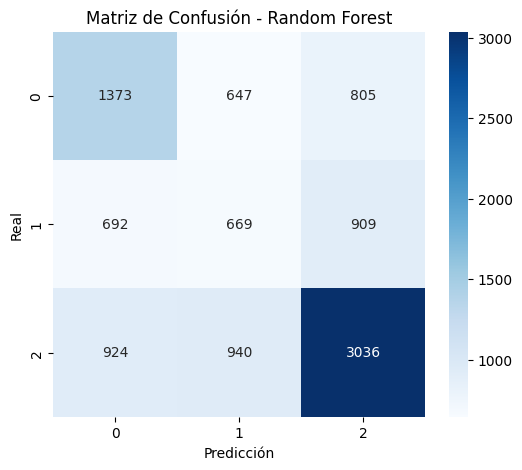

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

           0       0.46      0.49      0.47      2825
           1       0.30      0.29      0.30      2270
           2       0.64      0.62      0.63      4900

    accuracy                           0.51      9995
   macro avg       0.47      0.47      0.47      9995
weighted avg       0.51      0.51      0.51      9995



In [85]:
# MAtriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred_rf))


In [86]:
# AUC MULTICLASE
classes = rf_model.classes_

y_test_bin = label_binarize(y_test, classes=classes)

# AUC
auc_macro = roc_auc_score(y_test_bin, y_proba_rf, average='macro', multi_class='ovr')
auc_weighted = roc_auc_score(y_test_bin, y_proba_rf, average='weighted', multi_class='ovr')

print(f"AUC Macro: {auc_macro:.4f}")
print(f"AUC Weighted: {auc_weighted:.4f}")

AUC Macro: 0.6560
AUC Weighted: 0.6694


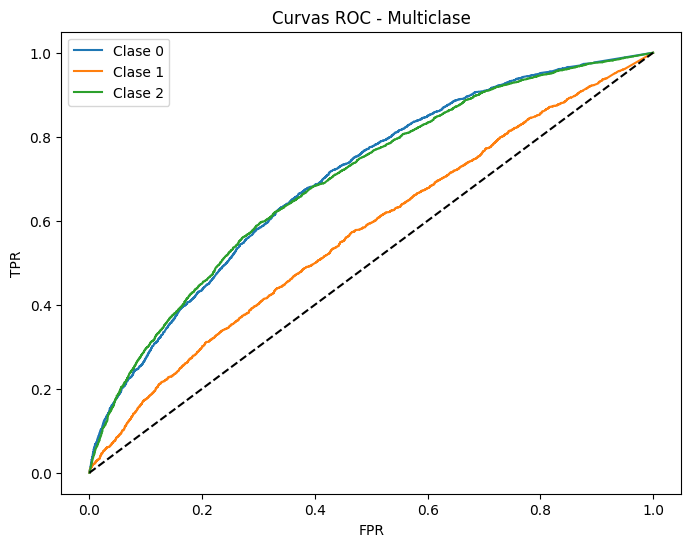

In [87]:
# Curvas ROC
plt.figure(figsize=(8,6))

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_rf[:, i])
    plt.plot(fpr, tpr, label=f'Clase {class_label}')

plt.plot([0,1], [0,1], 'k--')
plt.title('Curvas ROC - Multiclase')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

In [88]:
gini_macro = 2 * auc_macro - 1
print(f"Gini (macro): {gini_macro:.4f}")


Gini (macro): 0.3121


In [89]:
# KS
def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)

print("\nKS por clase:")
for i, class_label in enumerate(classes):
    ks = ks_statistic(y_test_bin[:, i], y_proba_rf[:, i])
    print(f"Clase {class_label}: KS = {ks:.4f}")


KS por clase:
Clase 0: KS = 0.2932
Clase 1: KS = 0.1074
Clase 2: KS = 0.2925


In [90]:
# Errores
errors = X_test.copy()
errors['y_true'] = y_test.values
errors['y_pred'] = y_pred_rf
errors['correct'] = (errors['y_true'] == errors['y_pred'])

error_rate = 1 - errors['correct'].mean()
print(f"\nError rate: {error_rate:.4f}")

# Ver ejemplos de errores
print("\nEjemplos de errores:")
display(errors[errors['correct'] == False].head())


Error rate: 0.4919

Ejemplos de errores:


,home_rank_position,home_rank_points,away_rank_position,away_rank_points,rank_points_diff,rank_position_diff,rank_points_sum,rank_points_ratio,abs_rank_points_diff,log_home_rank_points,...,tourn_World Cup,tourn_World Cup - Qualification CONCACAF,tourn_World Cup - Qualification Europe,tourn_World Cup - Qualification Intercontinental Play-offs,tourn_World Unity Cup,tourn_Zambian Independence Tournament,tourn_Évence Coppée Trophy,y_true,y_pred,correct
22871,128.0,1128.50,1.0,1877.18,-748.68,-127.0,3005.68,0.600848,748.68,7.029530,...,0,0,0,0,0,0,0,2,0,False
19596,49.0,1465.78,57.0,1447.31,18.47,8.0,2913.09,1.012062,18.47,7.290825,...,0,0,0,0,0,0,0,1,2,False
37987,40.0,1501.50,53.0,1461.46,40.04,13.0,2962.96,1.026695,40.04,7.314886,...,0,0,0,0,0,0,0,2,1,False
40223,65.0,1379.54,51.0,1464.24,-84.70,-14.0,2843.78,0.941511,84.70,7.230230,...,0,0,0,0,0,0,0,1,2,False
33709,24.0,1585.51,18.0,1654.69,-69.18,-6.0,3240.20,0.957613,69.18,7.369292,...,0,0,0,0,0,0,0,0,2,False


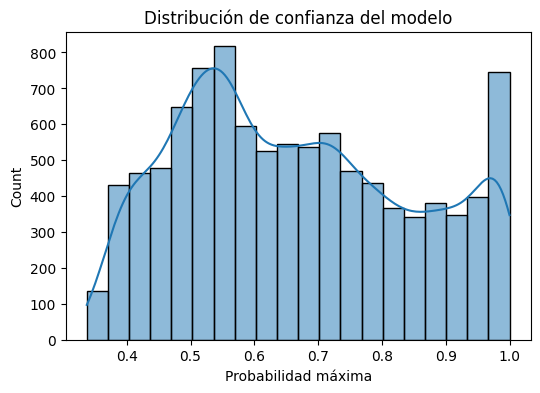

In [91]:
# Ps
confidence = np.max(y_proba_rf, axis=1)

plt.figure(figsize=(6,4))
sns.histplot(confidence, bins=20, kde=True)
plt.title('Distribución de confianza del modelo')
plt.xlabel('Probabilidad máxima')
plt.show()

**Conclusión:** No es mejor sin la variable 'year'. De hecho, el modelo empeora ligeramente. Esto sugiere que 'year' aporta información relevante para la predicción, posiblemente capturando tendencias temporales o cambios en el rendimiento de los equipos a lo largo del tiempo. Por lo tanto, es recomendable mantener 'year' como parte de las características del modelo.

--> Por lo tanto, se toma el primer modelo entrenado con todas las variables

## Regresión logística multinomial

In [96]:
# Definir modelo
lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced'
)

In [97]:
# Entrenar modelo
lr_model.fit(X_train, y_train)

/Users/dafnee/Documents/python/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/dafnee/Documents/python/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


In [98]:
# Predicciones
y_pred = lr_model.predict(X_test)
y_proba = lr_model.predict_proba(X_test)

In [99]:
y_pred

array([0, 2, 2, ..., 1, 2, 1], shape=(9995,))

In [100]:
y_proba

array([[0.64183036, 0.2518303 , 0.10633934],
       [0.1620025 , 0.35036511, 0.48763239],
       [0.18508359, 0.28345771, 0.5314587 ],
       ...,
       [0.36974914, 0.40138122, 0.22886964],
       [0.18633553, 0.34146596, 0.47219851],
       [0.36755938, 0.4489315 , 0.18350913]], shape=(9995, 3))

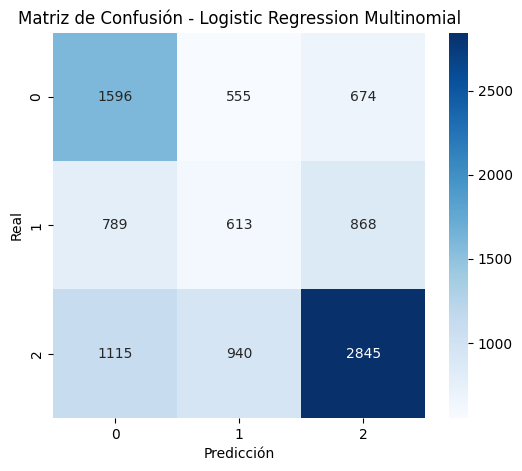

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

           0       0.46      0.56      0.50      2825
           1       0.29      0.27      0.28      2270
           2       0.65      0.58      0.61      4900

    accuracy                           0.51      9995
   macro avg       0.47      0.47      0.47      9995
weighted avg       0.51      0.51      0.51      9995



In [101]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Logistic Regression Multinomial')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred))

In [102]:
# AUC
classes = lr_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)

auc_macro = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
auc_weighted = roc_auc_score(y_test_bin, y_proba, average='weighted', multi_class='ovr')
print(f"AUC Macro: {auc_macro:.4f}")
print(f"AUC Weighted: {auc_weighted:.4f}")

AUC Macro: 0.6642
AUC Weighted: 0.6763


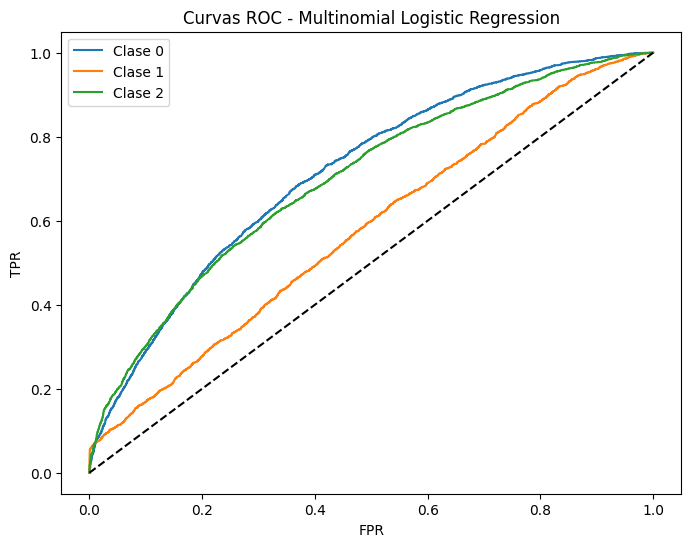

In [103]:
# Curvas ROC 
plt.figure(figsize=(8,6))
for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f'Clase {c}')
plt.plot([0,1],[0,1],'k--')
plt.title('Curvas ROC - Multinomial Logistic Regression')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

In [104]:
# Gini
gini_macro = 2 * auc_macro - 1
print(f"Gini (macro): {gini_macro:.4f}")

Gini (macro): 0.3284


In [105]:
# KS
def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)

print("\nKS por clase:")
for i, c in enumerate(classes):
    ks = ks_statistic(y_test_bin[:, i], y_proba[:, i])
    print(f"Clase {c}: KS = {ks:.4f}")


KS por clase:
Clase 0: KS = 0.3155
Clase 1: KS = 0.1043
Clase 2: KS = 0.2884


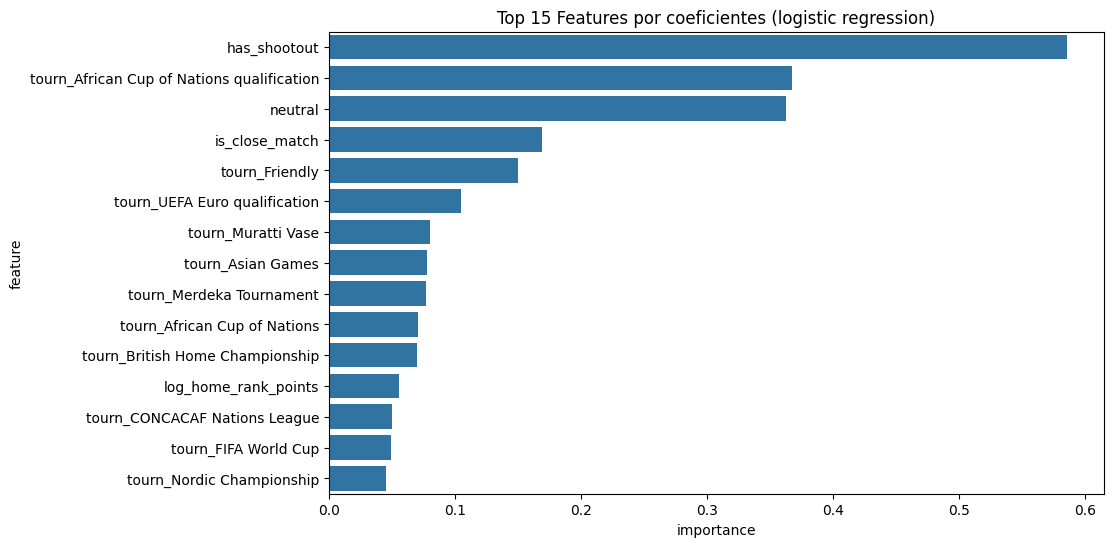

In [106]:
# Importancia de features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(lr_model.coef_[0])  # valor absoluto de coeficientes de la primera clase
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Top 15 Features por coeficientes (logistic regression)')
plt.show()

In [107]:
# Errores
errors = X_test.copy()
errors['y_true'] = y_test.values
errors['y_pred'] = y_pred
errors['correct'] = (errors['y_true'] == errors['y_pred'])
error_rate = 1 - errors['correct'].mean()
print(f"\nError rate: {error_rate:.4f}")

print("\nEjemplos de errores:")
display(errors[errors['correct'] == False].head())



Error rate: 0.4943

Ejemplos de errores:


,home_rank_position,home_rank_points,away_rank_position,away_rank_points,rank_points_diff,rank_position_diff,rank_points_sum,rank_points_ratio,abs_rank_points_diff,log_home_rank_points,...,tourn_World Cup,tourn_World Cup - Qualification CONCACAF,tourn_World Cup - Qualification Europe,tourn_World Cup - Qualification Intercontinental Play-offs,tourn_World Unity Cup,tourn_Zambian Independence Tournament,tourn_Évence Coppée Trophy,y_true,y_pred,correct
22871,128.0,1128.50,1.0,1877.18,-748.68,-127.0,3005.68,0.600848,748.68,7.029530,...,0,0,0,0,0,0,0,2,0,False
19596,49.0,1465.78,57.0,1447.31,18.47,8.0,2913.09,1.012062,18.47,7.290825,...,0,0,0,0,0,0,0,1,2,False
34206,135.0,1105.10,91.0,1256.69,-151.59,-44.0,2361.79,0.878674,151.59,7.008596,...,0,0,0,0,0,0,0,2,0,False
33709,24.0,1585.51,18.0,1654.69,-69.18,-6.0,3240.20,0.957613,69.18,7.369292,...,0,0,0,0,0,0,0,0,1,False
10531,51.0,1464.24,33.0,1540.43,-76.19,-18.0,3004.67,0.949923,76.19,7.289774,...,0,0,0,0,0,0,0,2,1,False


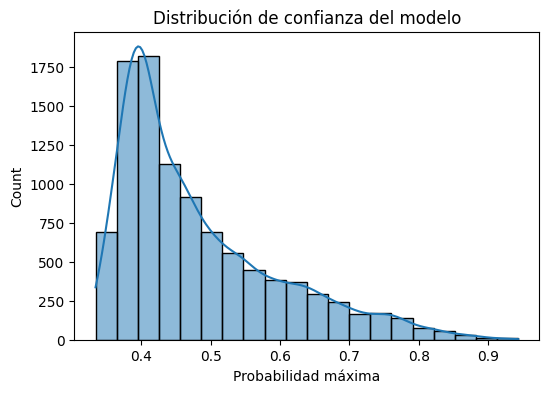

In [109]:
# Ps
confidence = np.max(y_proba, axis=1)

plt.figure(figsize=(6,4))
sns.histplot(confidence, bins=20, kde=True)
plt.title('Distribución de confianza del modelo')
plt.xlabel('Probabilidad máxima')
plt.show()